In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('loan_dataset.csv')

In [3]:
df=data.copy()

In [4]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,NaN,No,9600000,29900000,12,778,2400000.0,17600000.0,NaN,8000000.0,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,NaN,2200000.0,8800000.0,3300000.0,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000.0,NaN,33300000.0,12800000.0,Rejected
3,4,3,NaN,No,8200000,30700000,8,467,18200000.0,3300000.0,23300000.0,7900000.0,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000.0,8200000.0,29400000.0,5000000.0,Rejected


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_id                   4269 non-null   int64  
 1   no_of_dependents          4269 non-null   int64  
 2   education                 3629 non-null   object 
 3   self_employed             3928 non-null   object 
 4   income_annum              4269 non-null   int64  
 5   loan_amount               4269 non-null   int64  
 6   loan_term                 4269 non-null   int64  
 7   cibil_score               4269 non-null   int64  
 8   residential_assets_value  3885 non-null   float64
 9   commercial_assets_value   4141 non-null   float64
 10  luxury_assets_value       4013 non-null   float64
 11  bank_asset_value          3843 non-null   float64
 12  loan_status               4269 non-null   object 
dtypes: float64(4), int64(6), object(3)
memory usage: 433.7+ KB


In [6]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,3.885000e+03,4.141000e+03,4.013000e+03,3.843000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.471197e+06,4.974934e+06,1.509556e+07,4.960161e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.513098e+06,4.377911e+06,9.128965e+06,3.229474e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.450000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [7]:
df.isnull().mean()*100

loan_id                      0.000000
no_of_dependents             0.000000
education                   14.991801
self_employed                7.987819
income_annum                 0.000000
loan_amount                  0.000000
loan_term                    0.000000
cibil_score                  0.000000
residential_assets_value     8.995081
commercial_assets_value      2.998360
luxury_assets_value          5.996721
bank_asset_value             9.978918
loan_status                  0.000000
dtype: float64

In [8]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [9]:
# droping unrelated column

df.drop('loan_id',axis=1,inplace=True)

In [10]:
df.shape

(4269, 12)

In [11]:
categorical=[]
numerical=[]

for col in df:
    if df[col].dtype=='O':
        categorical.append(col)
        
    else:
        numerical.append(col)

In [12]:
# removing leading and trailing spaces from cols

df[categorical]=df[categorical].apply(lambda x:x.str.strip())

In [13]:

print("categorical cols:",categorical)
print()
print("numerical cols:",numerical)

categorical cols: ['education', 'self_employed', 'loan_status']

numerical cols: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


# <center>====Graphical representation of columns====</center>

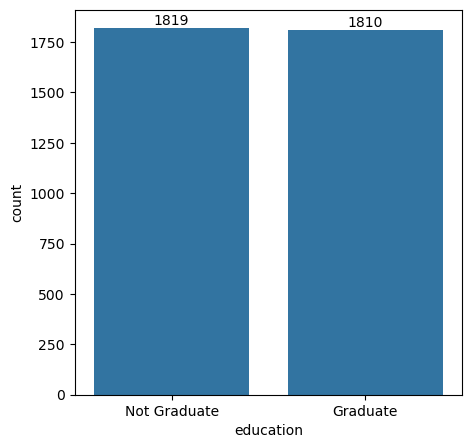

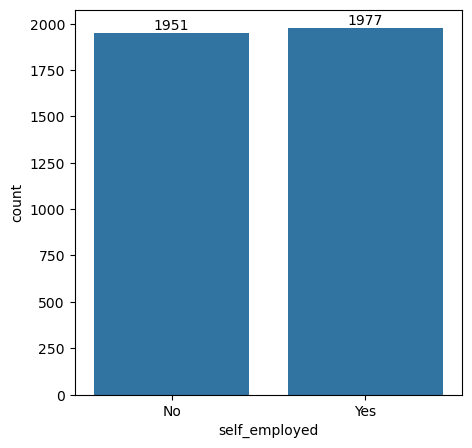

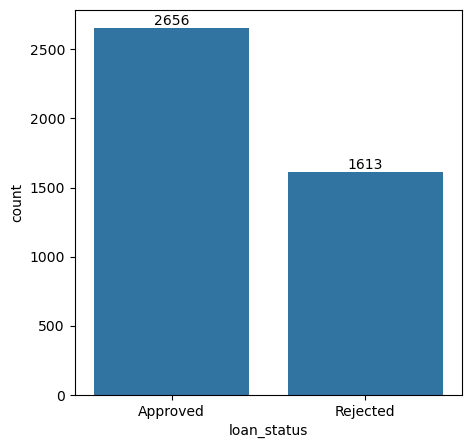

In [14]:
# countplot

for col in df[categorical]:
    plt.figure(figsize=(5,5))
    ax=sns.countplot(df[categorical],x=col)
    for bar in ax.containers:
        ax.bar_label(bar)
    

In [15]:
df['education'].unique()

array([nan, 'Not Graduate', 'Graduate'], dtype=object)

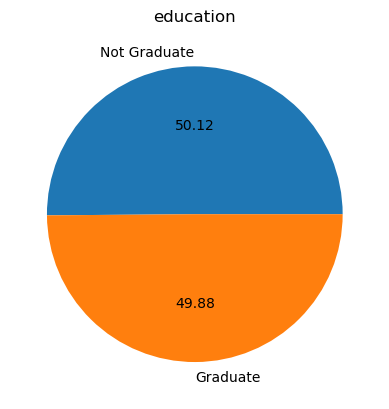

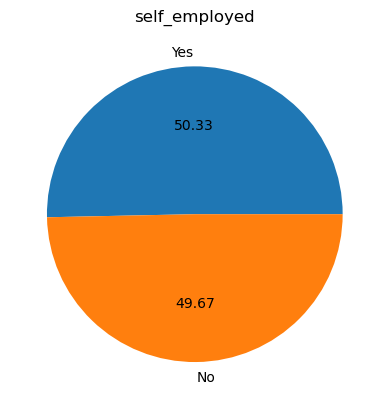

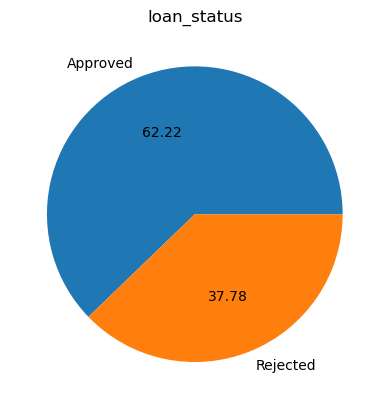

In [16]:
# pie chart of cols

for col in df[categorical]:
    df[col].value_counts()
    
    value=df[col].value_counts()
    index=df[col].value_counts().index
    
    plt.pie(x=value,labels=index,autopct='%.2f')
    plt.title(col)
    plt.show() 
    

> From the above graphs we see that in education column percentage of <b>Not Graduate(50.12%)</b> and <b>Graduate(49.88%)</b>
  is almost same . 
  
> And same for self employed column where percentage of <b>self employed(50.33%) and Not self employed(49.67%)</b> 
  is also almost equal.
  
> In Loan status column percentage of <b>Approved(62.22%) and rejected(37.78%).</b>

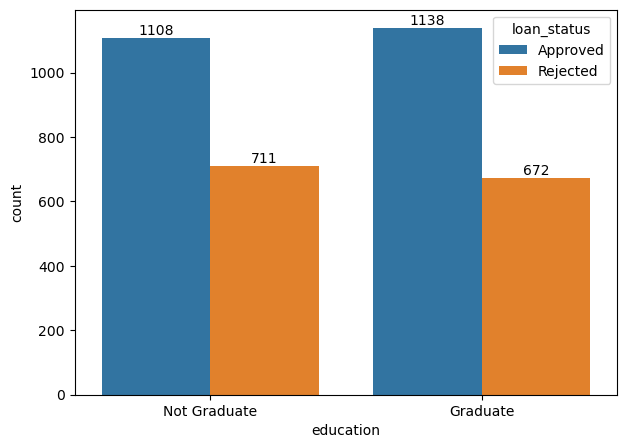

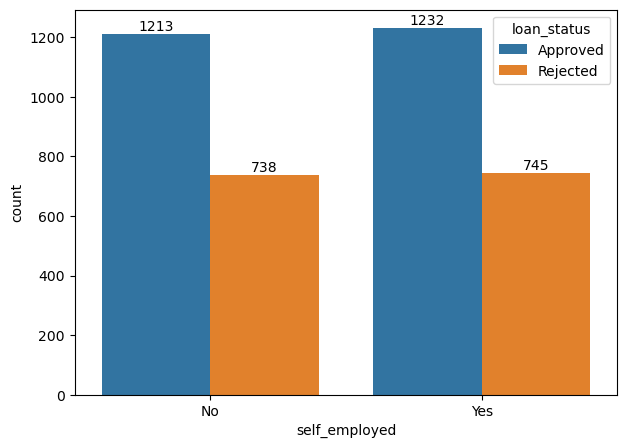

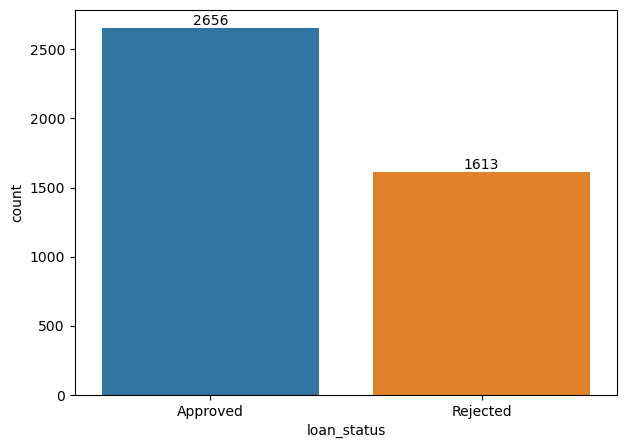

In [17]:
for col in df[categorical]:
    plt.figure(figsize=(7,5))
    ax=sns.countplot(df[categorical],x=col,hue='loan_status')
    for bar in ax.containers:
        ax.bar_label(bar)


> From the above graphs we can analysis that education does not affect the loan status as <b>Graduate and Not Graduate</b>
  people have almost same level of loan approved and reject.

> And same for self employment as <b>self employed people and Not self employed people</b> have almost same level of loan 
  approved and reject.

# <center>====Analysing Relation between columns====</center>

In [18]:
df[numerical].corr()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
no_of_dependents,1.000000,0.007266,-0.003366,-0.020111,-0.009998,0.006737,0.000216,0.002386,0.015848
income_annum,0.007266,1.000000,0.927470,0.011488,-0.023034,0.640718,0.641498,0.930093,0.850424
loan_amount,-0.003366,0.927470,1.000000,0.008437,-0.017035,0.597658,0.605096,0.862732,0.787576
loan_term,-0.020111,0.011488,0.008437,1.000000,0.007810,0.001318,-0.005899,0.013522,0.016951
cibil_score,-0.009998,-0.023034,-0.017035,0.007810,1.000000,-0.019119,-0.003302,-0.032040,-0.010174
residential_assets_value,0.006737,0.640718,0.597658,0.001318,-0.019119,1.000000,0.423827,0.598418,0.527412
commercial_assets_value,0.000216,0.641498,0.605096,-0.005899,-0.003302,0.423827,1.000000,0.591514,0.550547
luxury_assets_value,0.002386,0.930093,0.862732,0.013522,-0.032040,0.598418,0.591514,1.000000,0.789462
bank_asset_value,0.015848,0.850424,0.787576,0.016951,-0.010174,0.527412,0.550547,0.789462,1.000000


<Axes: >

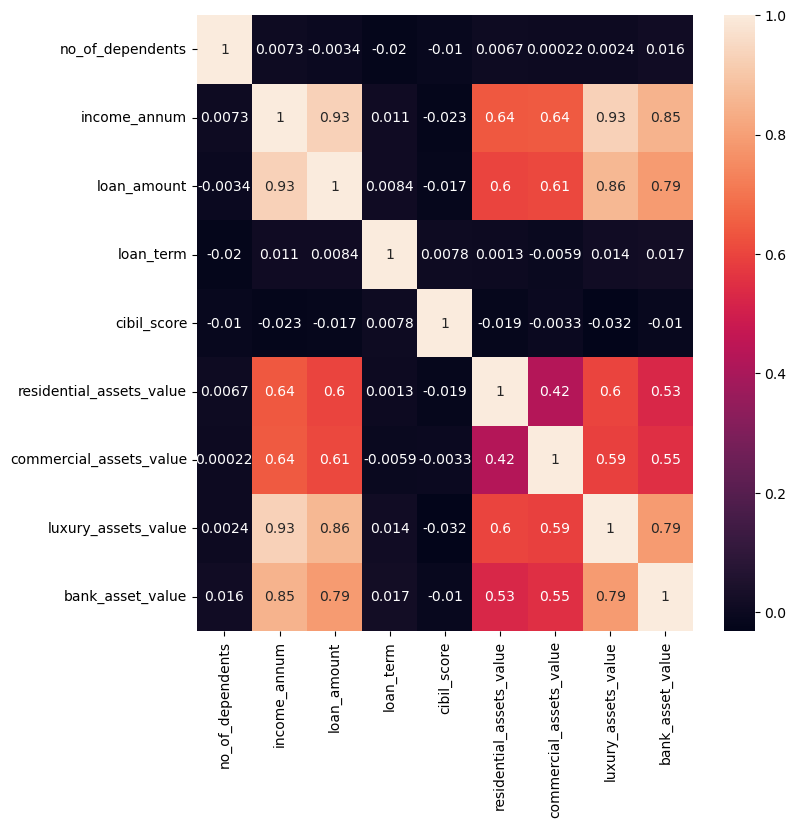

In [19]:
plt.figure(figsize=(8,8))
sns.heatmap(df[numerical].corr(),annot=True)

In [20]:
numerical

['no_of_dependents',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value']

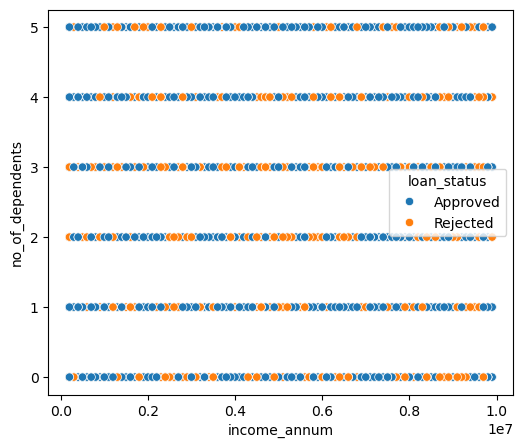

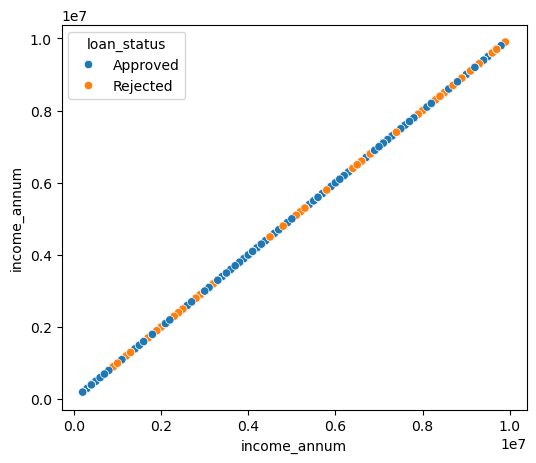

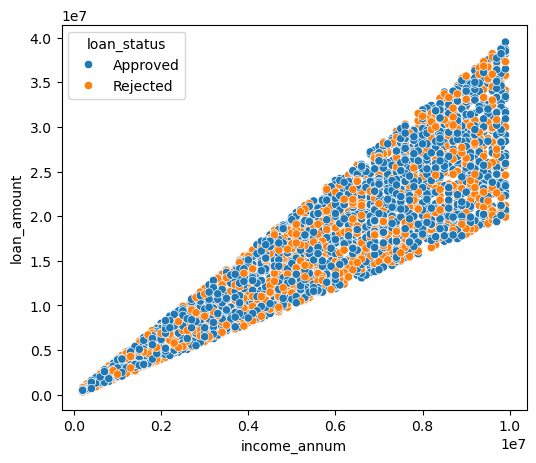

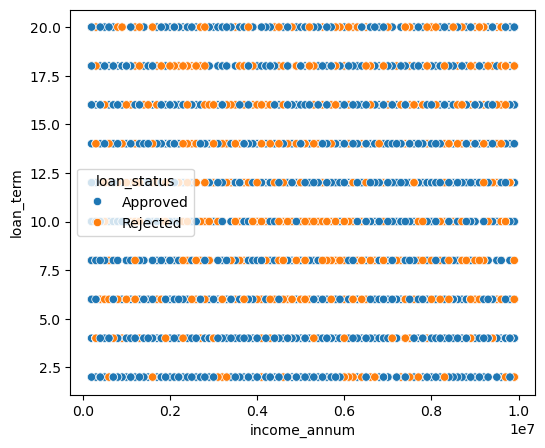

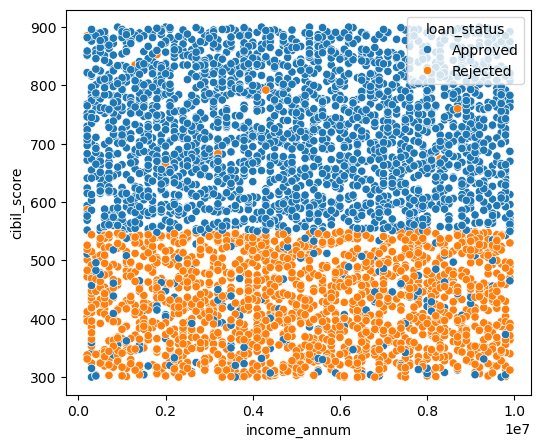

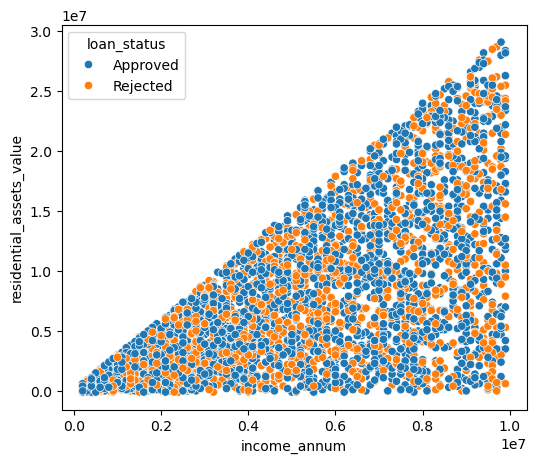

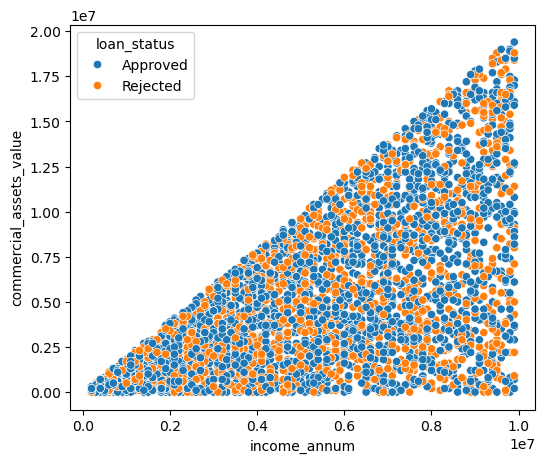

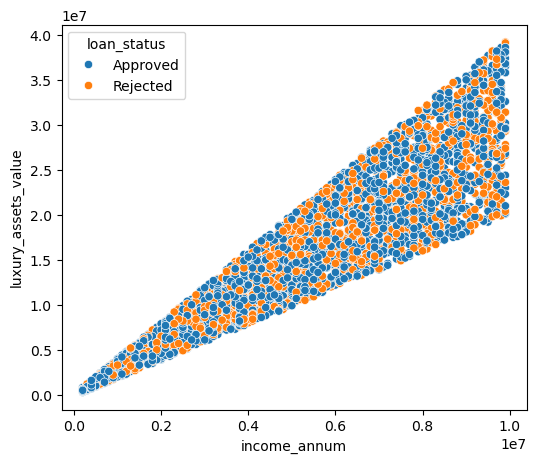

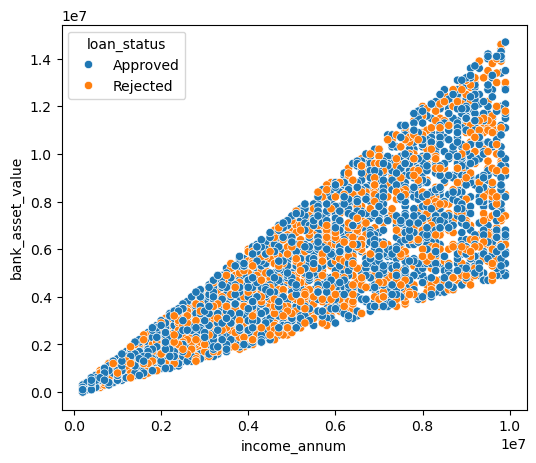

In [21]:
for num in df[numerical]:
    plt.figure(figsize=(6,5))
    sns.scatterplot(df,x='income_annum',y=num,hue='loan_status')    

> From the above graphs we can say that as income level increases than <b> bank_asset_value,luxury_assets_value ,
  commercial_assets_value,residential_assets_value and loan_amount</b> also increases/b>
  
> In <b>Cibil_score</b> it is very clear that people having score above than <b>550 have approved loan and below 
  than 550</b> are rejected. 

# <center>====Handling Missing Values====<center>

In [22]:
df.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

In [23]:
df.isnull().mean()*100

no_of_dependents             0.000000
education                   14.991801
self_employed                7.987819
income_annum                 0.000000
loan_amount                  0.000000
loan_term                    0.000000
cibil_score                  0.000000
residential_assets_value     8.995081
commercial_assets_value      2.998360
luxury_assets_value          5.996721
bank_asset_value             9.978918
loan_status                  0.000000
dtype: float64

In [24]:
print(categorical)
print()
print(numerical)

['education', 'self_employed', 'loan_status']

['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


# <center>Handling missing values on categorical columns<center>

In [25]:
df[categorical].isnull().sum()

education        640
self_employed    341
loan_status        0
dtype: int64

In [26]:
cat_missing_cols=df[categorical].iloc[:,:2]
cat_missing_cols.head()

,education,self_employed
0,NaN,No
1,Not Graduate,Yes
2,Graduate,No
3,NaN,No
4,Not Graduate,Yes


# <center>====Mode imputation====</center>

In [27]:
df_mode=df.copy()

In [28]:
df_mode[categorical].isnull().sum()

education        640
self_employed    341
loan_status        0
dtype: int64

In [29]:
 def mode_imputation(data,columns):
        data=df
        for col in columns:
            
            mode=df_mode[col].mode()[0]

            df_mode[col].value_counts()

            df_mode[col].fillna(mode,inplace=True)

In [30]:
mode_imputation(df_mode,cat_missing_cols)

In [31]:
df_mode[categorical].isnull().sum()

education        0
self_employed    0
loan_status      0
dtype: int64

# <center>Comparing graphs before and after imputation<center>

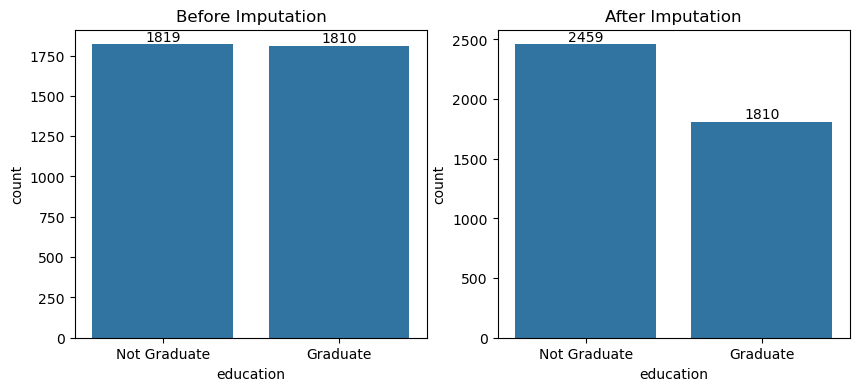

In [32]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Before Imputation')
ax=sns.countplot(df,x='education')
for bar in ax.containers:
    ax.bar_label(bar)


plt.subplot(1,2,2)
plt.title('After Imputation')
ax=sns.countplot(df_mode,x='education')
for bar in ax.containers:
    ax.bar_label(bar) 

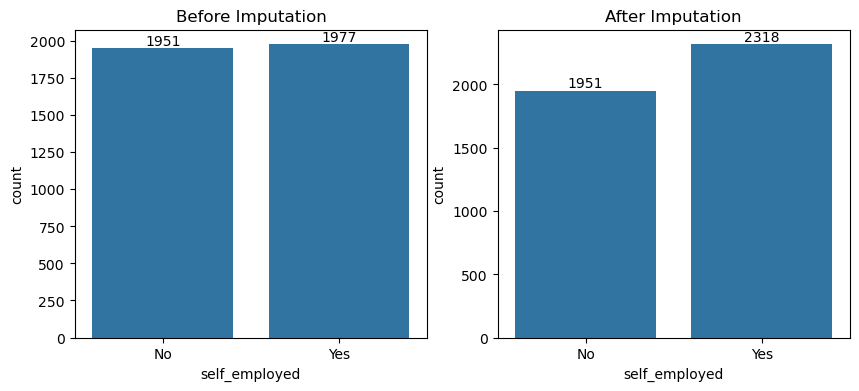

In [33]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Before Imputation')
ax=sns.countplot(df,x='self_employed')
for bar in ax.containers:
    ax.bar_label(bar)


plt.subplot(1,2,2)
plt.title('After Imputation')
ax=sns.countplot(df_mode,x='self_employed')
for bar in ax.containers:
    ax.bar_label(bar) 

> <b>Mode imputation</b> is not preferable here beacuse one category is dominating in both the columns after imputation 

# <center>====Random value  imputation====</center>

In [34]:
df_ran=df.copy()

In [35]:
df_ran.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

# <center>Random value imputation on education<center>

In [36]:
df_ran[categorical].isnull().sum()

education        640
self_employed    341
loan_status        0
dtype: int64

In [37]:
df['education'].value_counts()

education
Not Graduate    1819
Graduate        1810
Name: count, dtype: int64

In [38]:
not_null=df['education'].notnull().sum()
not_null

3629

In [39]:
not_gra=df[df['education']=='Not Graduate'].shape[0]
print(not_gra)

1819


In [40]:
gra=df[df['education']=='Graduate'].shape[0]
print(gra)

1810


In [41]:
# calculating probabilities

pro_not_gra=not_gra/not_null
pro_gra=gra/not_null

In [42]:
print("pro_not_gra:",pro_not_gra)
print("pro_gra:",pro_gra)

pro_not_gra: 0.5012400110223202
pro_gra: 0.4987599889776798


In [43]:
labels=df['education'].value_counts().index
print(labels)

Index(['Not Graduate', 'Graduate'], dtype='object', name='education')


In [44]:
# imputing values 

df_ran['education'].fillna(np.random.choice(labels,p=(pro_not_gra,pro_gra)),inplace=True)

# <center>Random value imputation on self_employed<center> 

In [45]:
df_ran[categorical].isnull().sum()

education          0
self_employed    341
loan_status        0
dtype: int64

In [46]:
df_ran['self_employed'].value_counts()

self_employed
Yes    1977
No     1951
Name: count, dtype: int64

In [47]:
labels1=df['self_employed'].value_counts().index
print(labels1)

Index(['Yes', 'No'], dtype='object', name='self_employed')


In [48]:
non_null1=df['self_employed'].notnull().sum()
print(non_null1)

3928


In [49]:
yes_count=df[df['self_employed']=='Yes'].shape[0]
yes_count

1977

In [50]:
no_count=df[df['self_employed']=='No'].shape[0]
no_count

1951

In [51]:
# calculating probabilities

pro_yes=yes_count/non_null1
pro_no=no_count/non_null1

In [52]:
print('pro_yes:',pro_yes)
print()
print('pro_no:',pro_no)

pro_yes: 0.5033095723014257

pro_no: 0.49669042769857435


In [53]:
#Imputing values
df_ran['self_employed'].fillna(np.random.choice(labels1,p=(pro_yes,pro_no)),inplace=True)

In [54]:
df_ran[categorical].isnull().sum()

education        0
self_employed    0
loan_status      0
dtype: int64

# <center>Comparing graphs before and after imputation<center>

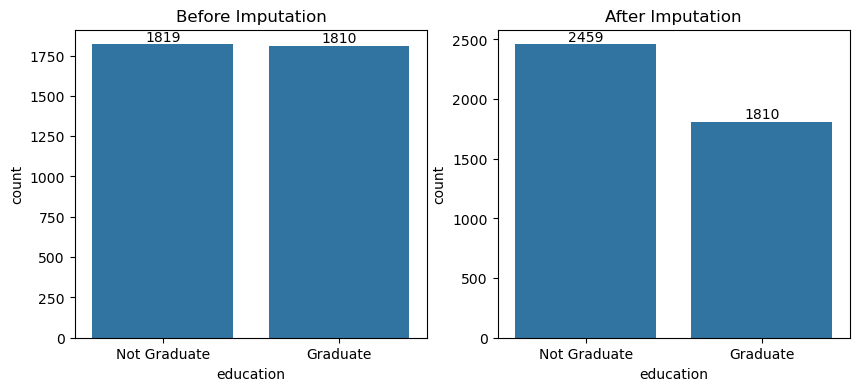

In [55]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Before Imputation')
ax=sns.countplot(df,x='education')
for bar in ax.containers:
    ax.bar_label(bar)

plt.subplot(1,2,2)
plt.title('After Imputation')
ax=sns.countplot(df_ran,x='education')
for bar in ax.containers:
    ax.bar_label(bar) 

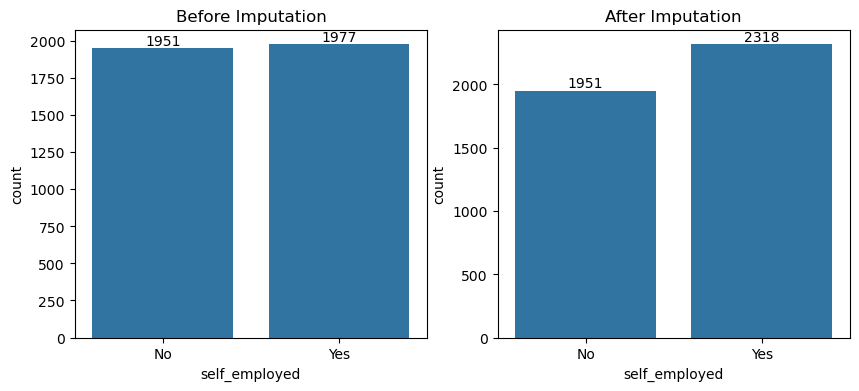

In [56]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Before Imputation')
ax=sns.countplot(df,x='self_employed')
for bar in ax.containers:
    ax.bar_label(bar)

plt.subplot(1,2,2)
plt.title('After Imputation')
ax=sns.countplot(df_ran,x='self_employed')
for bar in ax.containers:
    ax.bar_label(bar) 

> <b>Random value imputation</b> gives better results in education column but one category is dominating after imputation due to   which there is minimum difference between value count of both category

> where as in <b>self employed column</b> random value impuatation is preferable as there is less difference between value 
  count of both category after the imputation.

# <center>====Missing value indicator====<center> 

In [57]:
df_mis=df.copy()

In [58]:
df_mis[categorical].isnull().sum()

education        640
self_employed    341
loan_status        0
dtype: int64

In [59]:
for col in cat_missing_cols:
    df_mis[col].fillna('Missing',inplace=True)
    

In [60]:
df_mis[categorical].isnull().sum()

education        0
self_employed    0
loan_status      0
dtype: int64

# <center>Comparing graph before and after imputation<center>

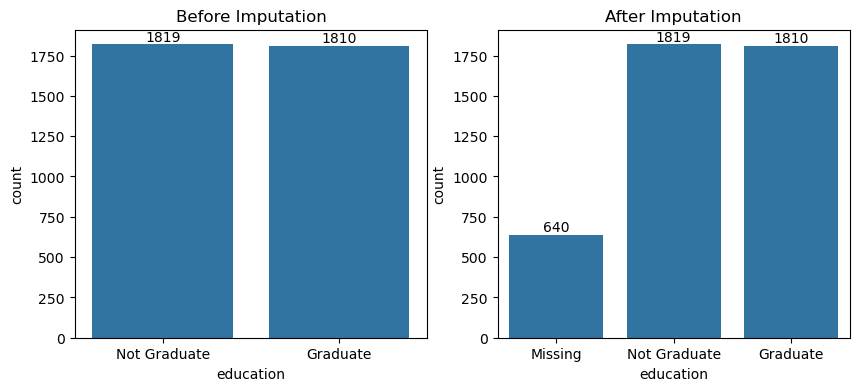

In [61]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Before Imputation')
ax=sns.countplot(df,x='education')
for bar in ax.containers:
    ax.bar_label(bar)

plt.subplot(1,2,2)
plt.title('After Imputation')
ax=sns.countplot(df_mis,x='education')
for bar in ax.containers:
    ax.bar_label(bar) 

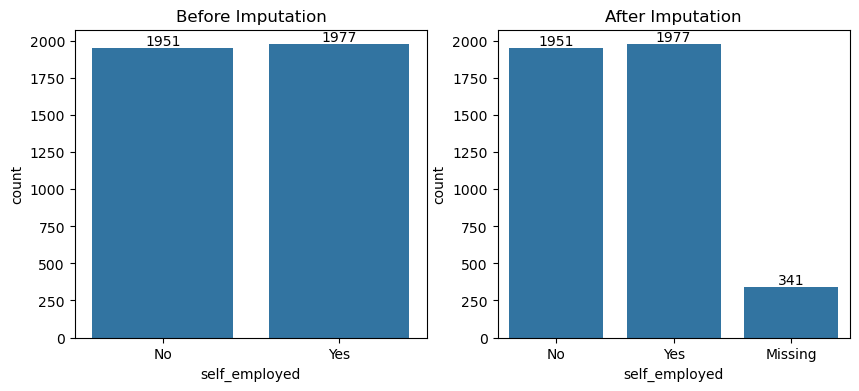

In [62]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Before Imputation')
ax=sns.countplot(df,x='self_employed')
for bar in ax.containers:
    ax.bar_label(bar)

plt.subplot(1,2,2)
plt.title('After Imputation')
ax=sns.countplot(df_mis,x='self_employed')
for bar in ax.containers:
    ax.bar_label(bar) 

# Conclusion:
> <b>Mode imputation and Random value imputation</b> both give almost same result after imputing values in <b>Education            column </b> and in both cases one category is dominating. 

> Random value imputation give better result than Mode imputation and Missing Indicator in <b>Self_employed column.</b>

> Altough Mode imputation and <b>Random Value Imputation</b> gives same results in both the columns but we will work with
  <b>Random value imputation</b> in categorical columns 

# <center>Handling Missing Values On Numerical Columns<center>

In [63]:
df[numerical].isnull().sum()

no_of_dependents              0
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
dtype: int64

# <center>Analysing distribution of numerical cols<center>

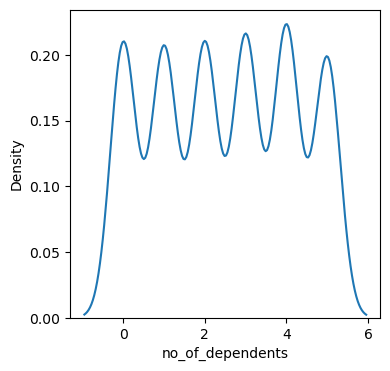

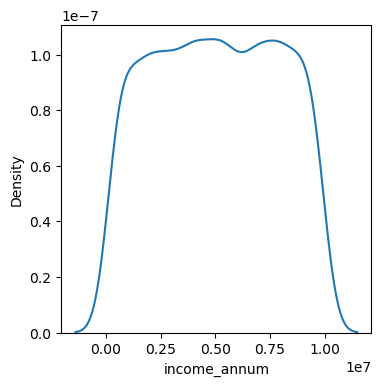

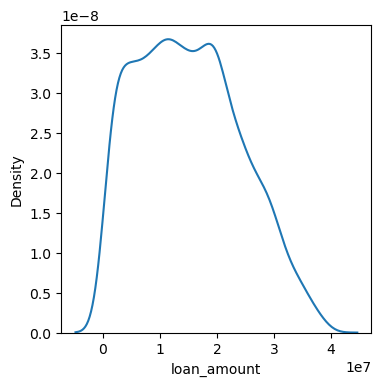

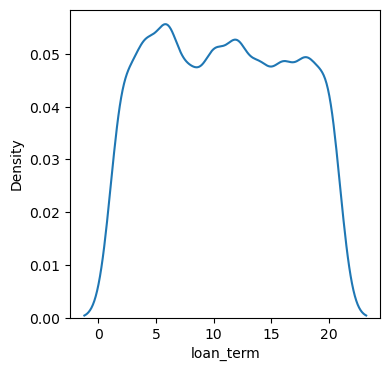

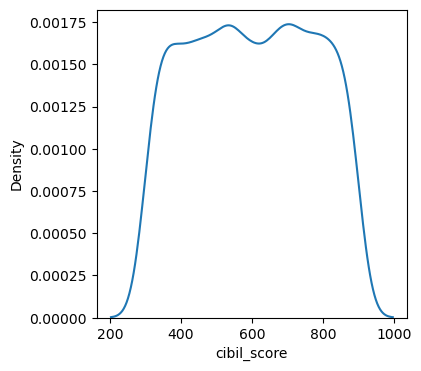

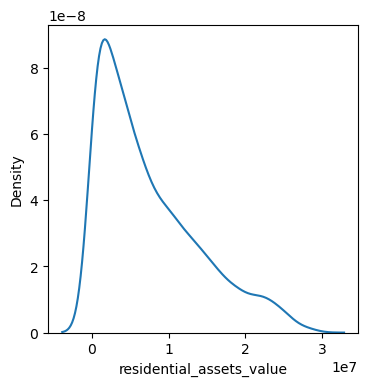

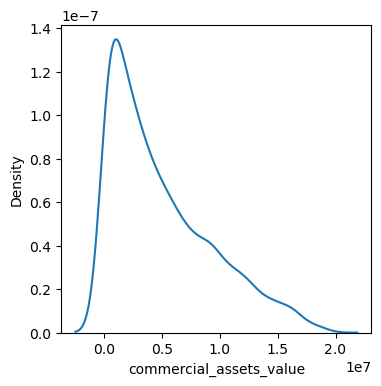

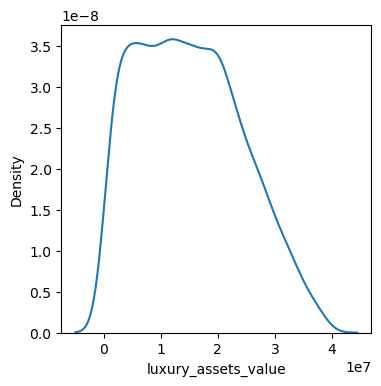

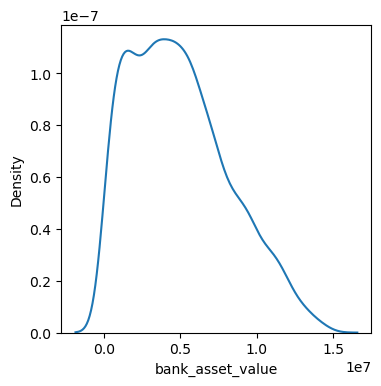

In [64]:
for num in df[numerical]:
    plt.figure(figsize=(4,4))
    sns.kdeplot(df,x=num)

In [65]:
num_missing_cols=df[numerical].iloc[:,5:]
num_missing_cols.isnull().head()

,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,False,False,True,False
1,True,False,False,False
2,False,True,False,False
3,False,False,False,False
4,False,False,False,False


# <center>====Mean Imputation====</center>

In [66]:
df_mean=df_ran.copy()

In [67]:
df_mean[numerical].isnull().sum()

no_of_dependents              0
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
dtype: int64

In [68]:
def meanimputation(data,columns):
    data=df
    
    for col in columns:
        mean=df_mean[col].mean() 
        df_mean[col].fillna(mean,inplace=True)
        

In [69]:
meanimputation(df_mean,num_missing_cols)

In [70]:
df_mean[numerical].isnull().sum()

no_of_dependents            0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
dtype: int64

# <center>Comparing distribution of columns before and after imputation<center>

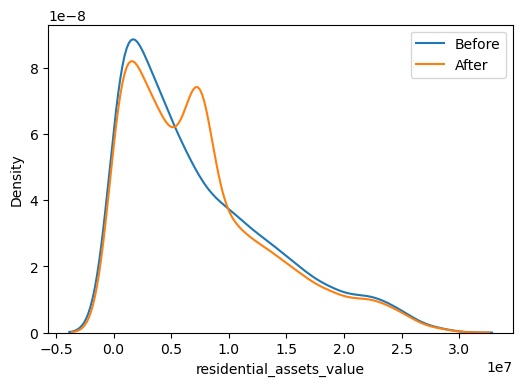

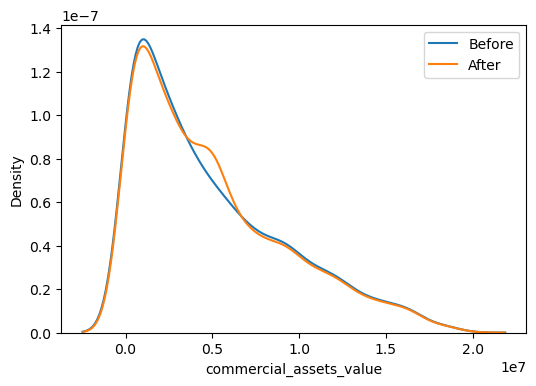

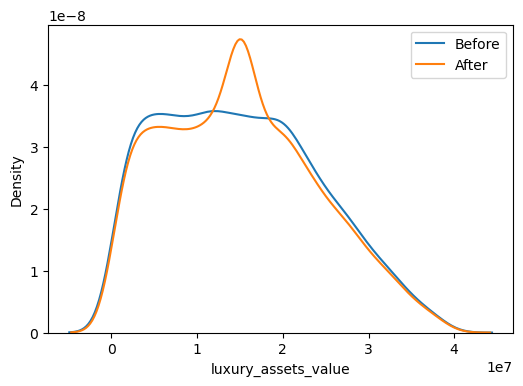

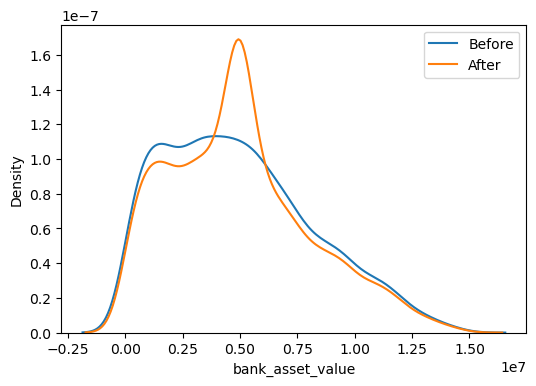

In [71]:
for col in num_missing_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df,x=col,label='Before')
    sns.kdeplot(df_mean,x=col,label='After')
    plt.legend()
    plt.show()

> Mean imputation is not preferable for <b>columns residential_assets_value,luxury_assets_value and bank_asset_value</b>
  because there are very big difference in distribution of data after the imputation in all three columns.
  
> But for <b>commercial_assets_value</b>  Mean imputation can be used as there is very less difference in distribution after             imputation.

# <center>====Median Imputation====<center>

In [72]:
df_mdn=df_ran.copy()

In [73]:
df_mdn[numerical].isnull().sum()

no_of_dependents              0
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
dtype: int64

In [74]:
def medianimputation(data,columns):
    data=df
    
    for col in columns:
        median=df_mdn[col].median() 
        df_mdn[col].fillna(median,inplace=True)
        

In [75]:
medianimputation(df_mdn,num_missing_cols)

In [76]:
df_mdn[numerical].isnull().sum()

no_of_dependents            0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
dtype: int64

# <center>Comparing distribution of columns before and after imputation<center>

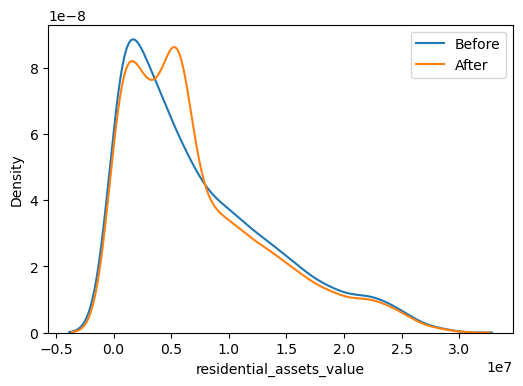

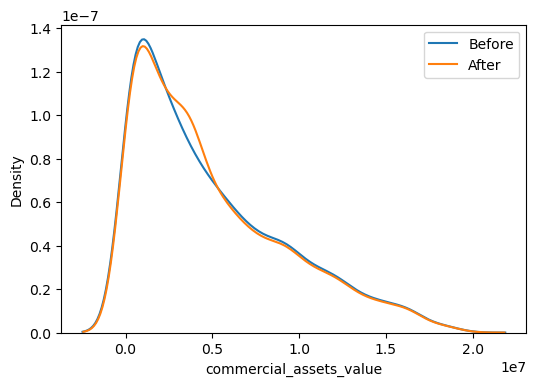

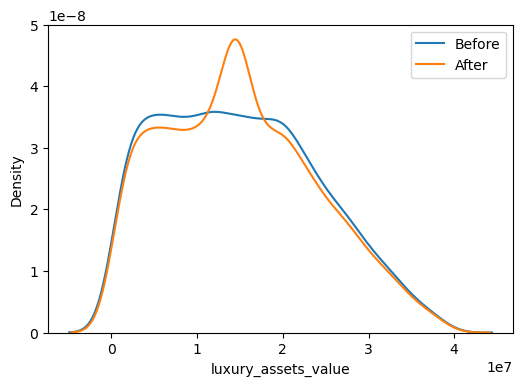

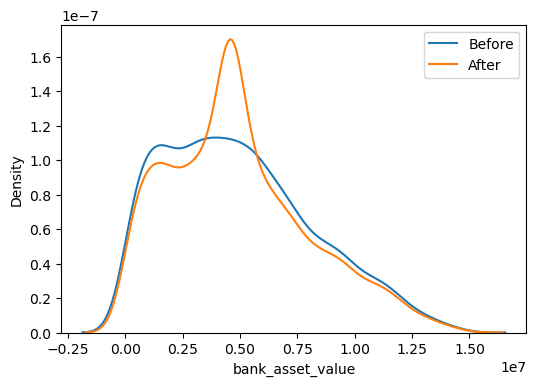

In [77]:
for col in num_missing_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df,x=col,label='Before')
    sns.kdeplot(df_mdn,x=col,label='After')
    plt.legend()
    plt.show()

> <b>Median Imputation</b> gives same reults like <b>Mean Imputation</b> and there are very big changes in distribution of 
  columns after imputation.
  
> So <b>Median Imputation</b> cannot be preferable here.


# <center>====Random Value Imputation====<center>

In [78]:
df_ran1=df_ran.copy()

In [79]:
df_ran1[numerical].isnull().sum()

no_of_dependents              0
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
dtype: int64

In [80]:
def randomvalueimputation(data,columns):
    data=df
    for col in columns:
        missing=df_ran1[col].isnull().sum()
        
        pool = df_ran1[col].dropna().sample(missing).values
        
        df_ran1[col][df_ran1[col].isnull()]=pool
        

In [81]:
randomvalueimputation(df_ran1,num_missing_cols)

In [82]:
df_ran1[numerical].isnull().sum()

no_of_dependents            0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
dtype: int64

# <center>Comparing distribution of columns before and after imputation<center>

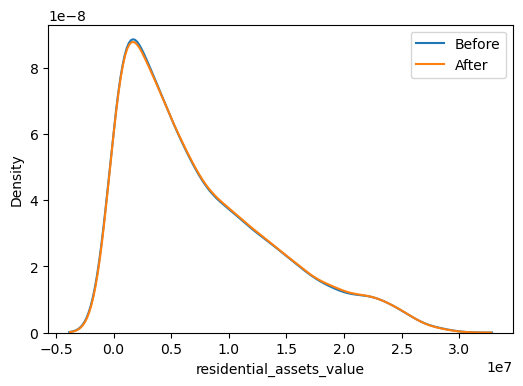

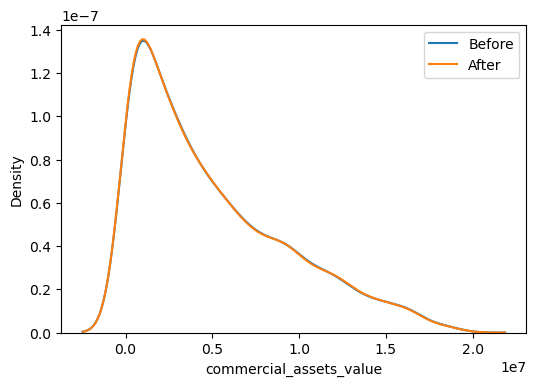

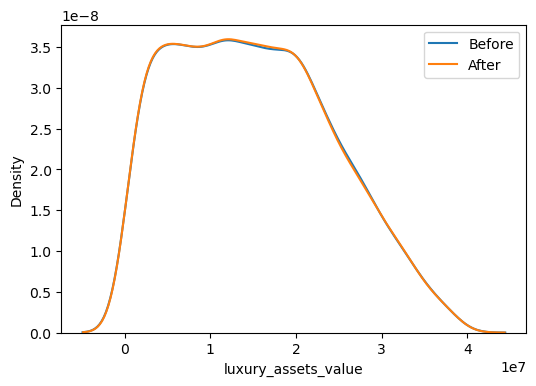

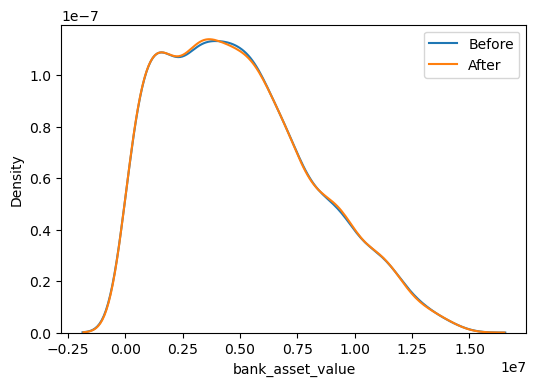

In [83]:
for col in num_missing_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df,x=col,label='Before')
    sns.kdeplot(df_ran1,x=col,label='After')
    plt.legend()
    plt.show()

> <b>Random value imputation</b> is preferable for all four columns as there's no changes in distribution of data after 
   imputation.
    

# <center>====KNN Imputer====<center>

In [116]:
knn=KNNImputer(n_neighbors=5)

In [117]:
df_knn=df_ran.copy()

In [118]:
df_knn[numerical].isnull().sum()

no_of_dependents              0
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
dtype: int64

In [119]:
df_knn=knn.fit_transform(df_knn[numerical])
df_knn=pd.DataFrame(data=df_knn,columns=numerical)

In [120]:
df_knn[numerical].isnull().sum()

no_of_dependents            0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
dtype: int64

In [121]:
df_knn.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2.0,9600000.0,29900000.0,12.0,778.0,2400000.0,17600000.0,28680000.0,8000000.0
1,0.0,4100000.0,12200000.0,8.0,417.0,7720000.0,2200000.0,8800000.0,3300000.0
2,3.0,9100000.0,29700000.0,20.0,506.0,7100000.0,5480000.0,33300000.0,12800000.0
3,3.0,8200000.0,30700000.0,8.0,467.0,18200000.0,3300000.0,23300000.0,7900000.0
4,5.0,9800000.0,24200000.0,20.0,382.0,12400000.0,8200000.0,29400000.0,5000000.0


# <center>Comparing distribution of columns before and after KNN imputation<center>

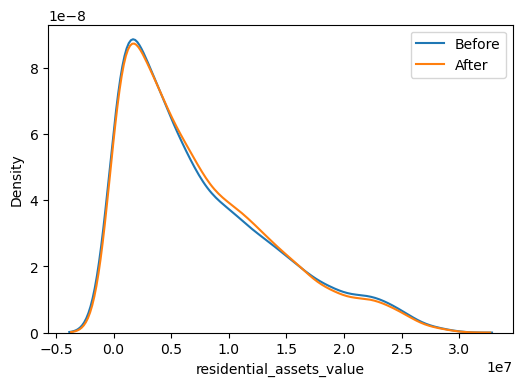

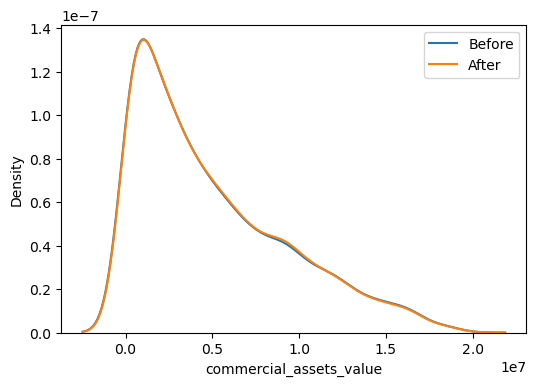

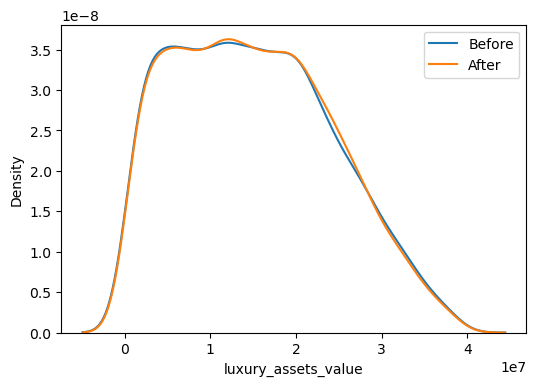

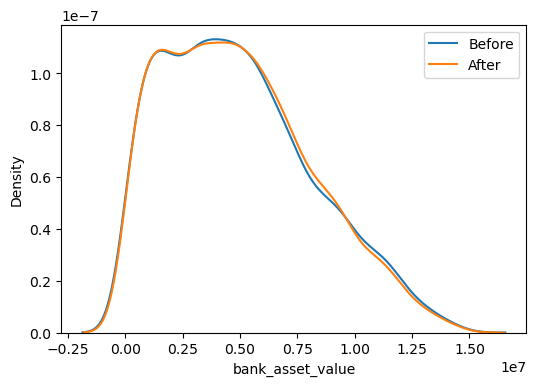

In [122]:
for col in num_missing_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df,x=col,label='Before')
    sns.kdeplot(df_knn,x=col,label='After')
    plt.legend()
    plt.show()

<b>kNN imputer</b> also gives good results and there's no changes in distribution of data after imputation.

# Conclusion:
> <b>Random Value Imputation and KNN Imputation </b> gives best reults on all four columns as compare to <b>Mean and Median     imputation</b> as   there is no changes in curves after imputation

> We will select <b>Random Value Imputation</b> on all numerical columns to handle missing values

# <center>====Identifying outliers====<center>

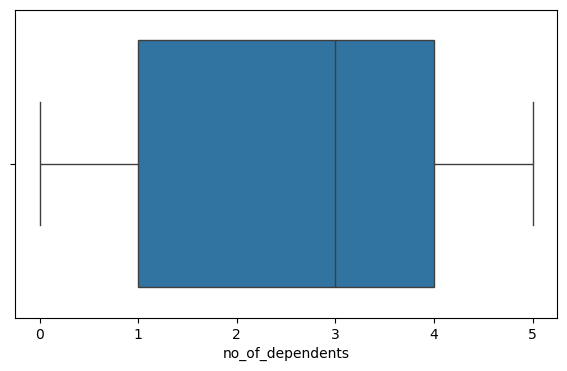

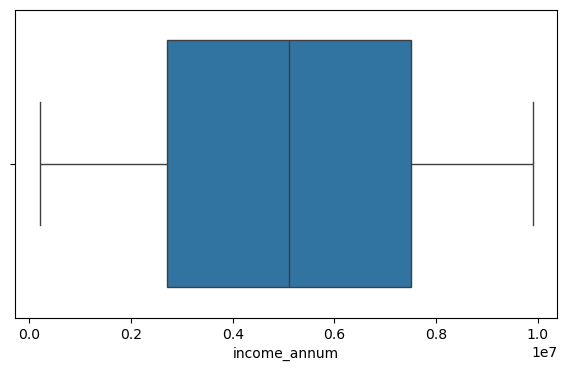

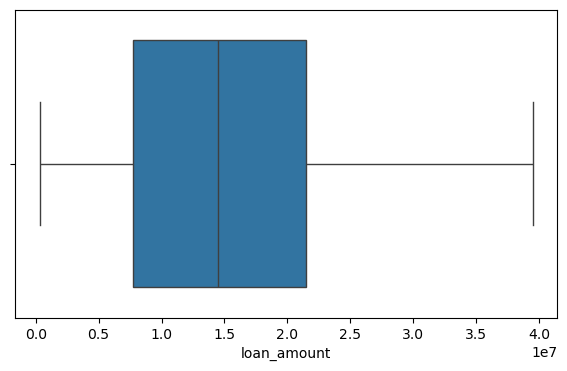

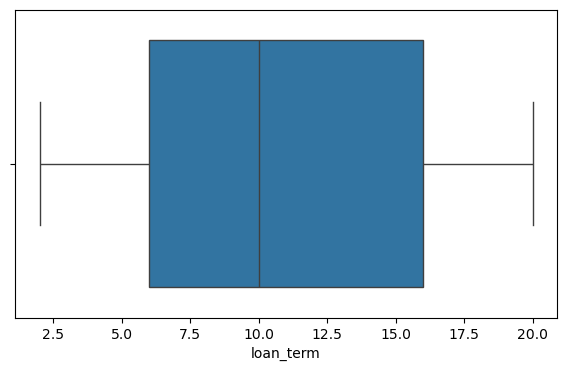

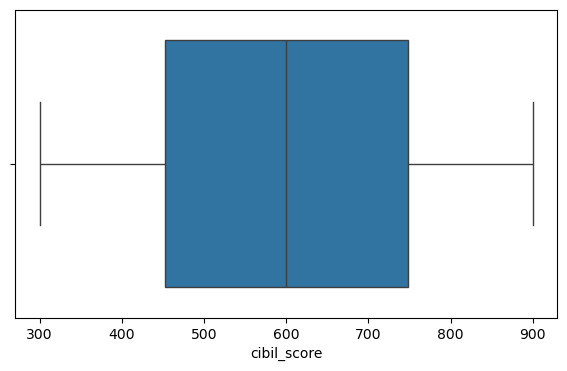

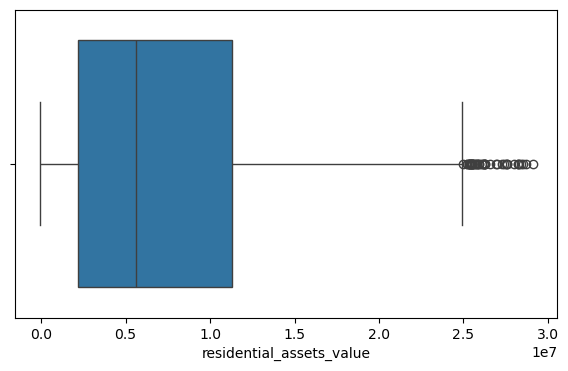

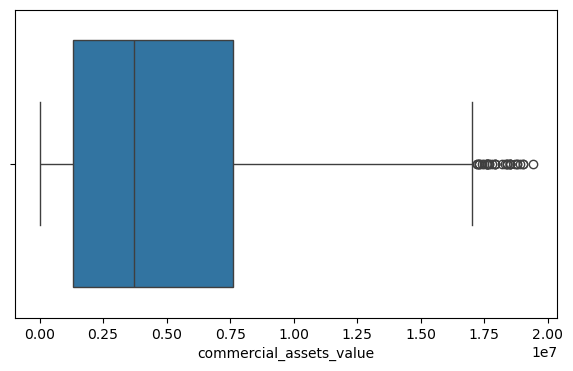

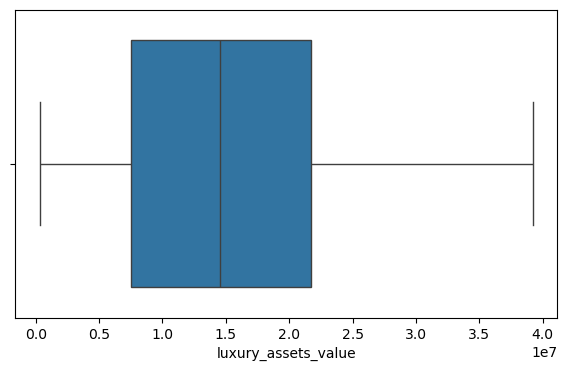

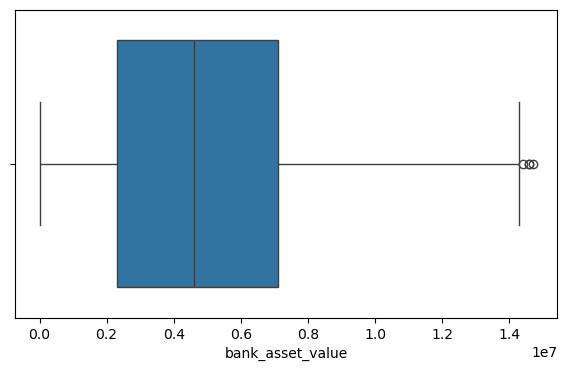

In [90]:
for num in df_ran1[numerical]:
    plt.figure(figsize=(7,4))
    sns.boxplot(df,x=num)

In [91]:
outliers_cols=['residential_assets_value','commercial_assets_value','bank_asset_value']

# <center>Handling outliers by boundary value method<center>

In [92]:
df1=df_ran1.copy()

In [93]:
def boundaryvale(data,columns):
    data=df
    
    for col in columns:
        ub=df1[col].mean()+3*df1[col].std()
        lb=df1[col].mean()-3*df1[col].std()


        df1[(df1[col]>ub) | (df1[col]<lb)]



        df1[(df1[col]<ub) & (df1[col]>lb)]


 
        df1[col]=np.where(df1[col]>ub,ub,np.where(df1[col]<lb,lb,df1[col]))

In [94]:
boundaryvale(df1,outliers_cols)

# <center> Comparing Curves before and after handling outliers by boundary value <center>

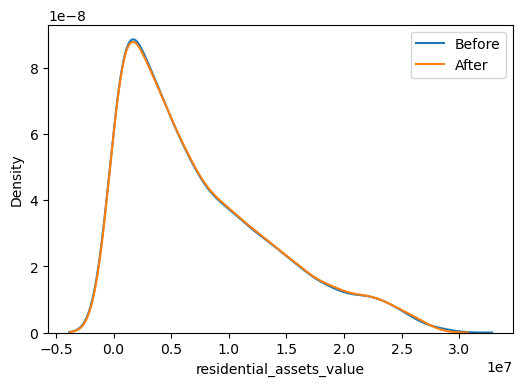

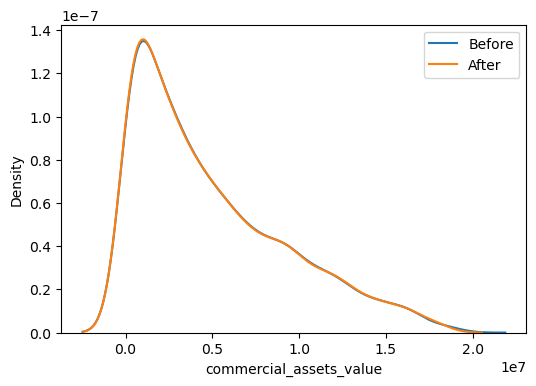

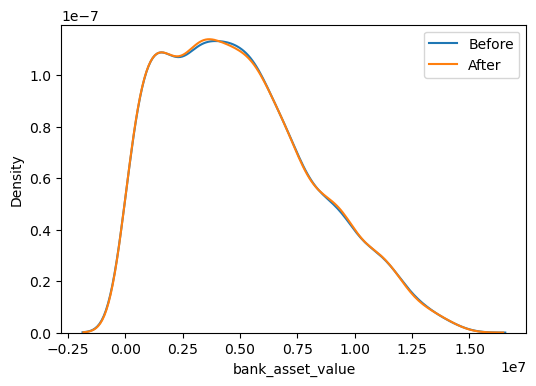

In [95]:
for col in outliers_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df,x=col,label='Before')
    sns.kdeplot(df1,x=col,label='After')
    plt.legend()
    plt.show()

> <b>Boundary Value Method</b> gives good result in all three columns as there's no changes in distribution of data in columns 
> after imputation.

# <center>Handling outliers by IQR method</center>

In [96]:
df2=df_ran1.copy()

In [97]:
def iqr_method(data,columns):
    data=df
    for col in columns:
        p25=df2[col].quantile(0.25)
        p75=df2[col].quantile(0.75)

        iqr=p75-p25
        uf=p75+1.5*iqr
        lf=p25-1.5*iqr

        df2[(df2[col]>uf) | (df2[col]<lf)]

        df2[(df2[col]<uf) & (df2[col]>lf)]

        df2[col]=np.where(df2[col]>uf,uf,np.where(df2[col]<lf,lf,df2[col]))

In [98]:
iqr_method(df2,outliers_cols)

# <center> Comparing Curves before and after handling outliers by iQR method <center>

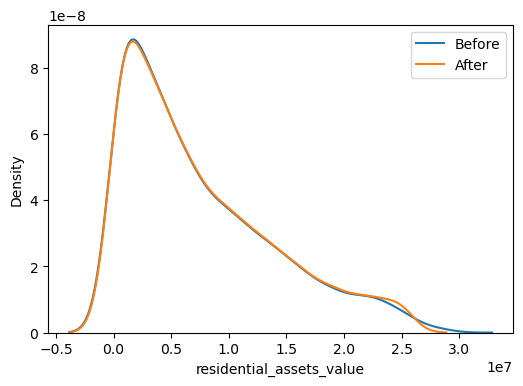

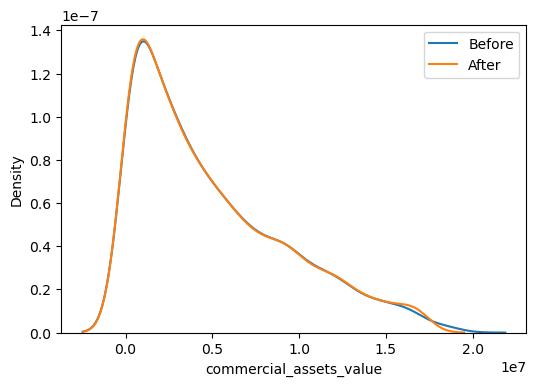

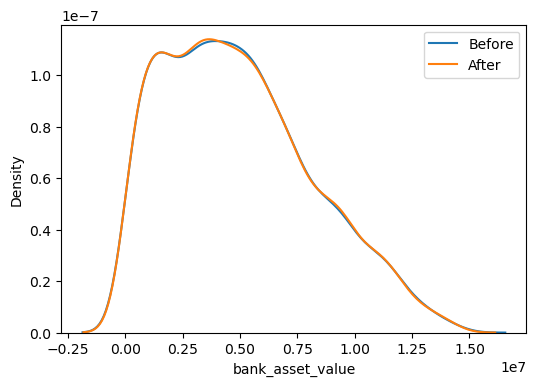

In [99]:
for col in outliers_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df,x=col,label='Before')
    sns.kdeplot(df2,x=col,label='After')
    plt.legend()
    plt.show()

> <b>IRQ Method</b> also gives good results on all three columns but on <b>residential_assets_value and commercial_assets_value</b>
> column there are small changes in distribution of data after handling outliers.

# <center>Handling outliers by Percentile Method</center>

In [100]:
df3=df_ran1.copy()

In [101]:
def percentile_method(data,columns):
    data=df
    
    for col in columns:
        ul=df3[col].quantile(0.95)
        ll=df3[col].quantile(0.05)


        df3[(df3[col]>ul) | (df3[col]<ll)]

        df3[(df3[col]<ul) & (df3[col]>ll)]

        df3[col]=np.where(df3[col]>ul,ul,np.where(df3[col]<ll,ll,df3[col]))

In [102]:
percentile_method(df3,outliers_cols)

# <center>Comparing curves before and after handling outliers by percentile method <center>

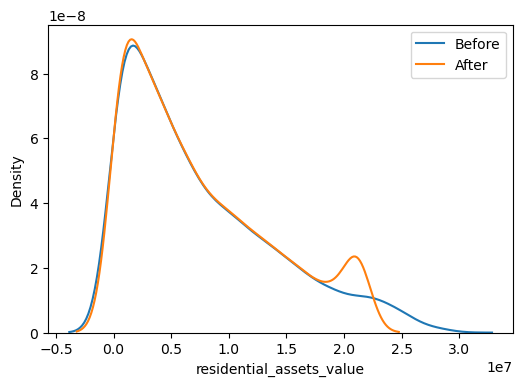

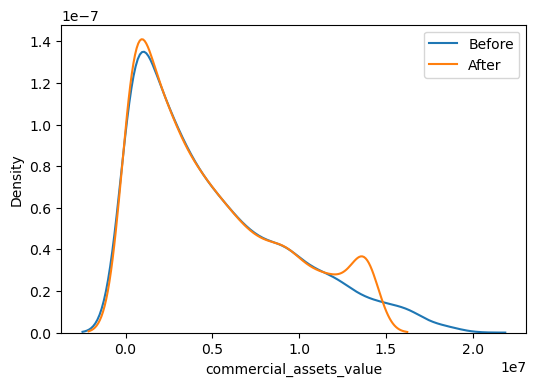

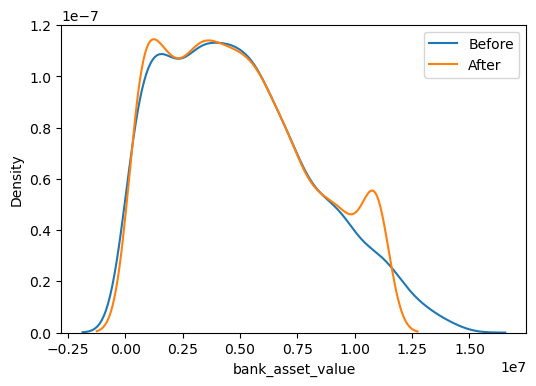

In [103]:
for col in outliers_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df,x=col,label='Before')
    sns.kdeplot(df3,x=col,label='After')
    plt.legend()
    plt.show()

> <b>Percentile Method</b> gives worst results while handling outliers in all three columns.because there are very big 
   changes in distribution of data after using percentile method

# Conclusion:
> Both <b>Boundary Value Method and IQR Method</b> gives some results and <b>Percentile Method</b> gives the worst results 
> in handling outliers.

> We will select <b>IQR method</b> for handling outliers